In [11]:

# 1: PROBLEM & DATASET

import pandas as pd
from sklearn.model_selection import train_test_split

print("=" * 60)
print("1. PROBLEM & DATASET")
print("=" * 60)

print("Masalah : Memprediksi apakah seorang pasien memiliki diabetes")
print("berdasarkan data kesehatan seperti glukosa, BMI, tekanan darah, dll.")

print("Tujuan : Membuat model Machine Learning yang mampu memprediksi")
print("risiko diabetes dengan akurasi yang baik.")

print("Sumber Dataset : Pima Indians Diabetes Dataset")
print("Link Dataset : https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv")

# Nama kolom dataset
columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

# Load dataset dari link
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

df = pd.read_csv(url, names=columns)

# Tampilkan info dasar
print("\nUkuran Dataset:")
print(df.shape)

print("\nNama Fitur:")
print(df.columns)

print("\n5 Data Pertama:")
print(df.head())

# Pisahkan fitur dan target
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

# Split train-test 80-20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nUkuran Data Train:", X_train.shape)
print("Ukuran Data Test :", X_test.shape)

1. PROBLEM & DATASET
Masalah : Memprediksi apakah seorang pasien memiliki diabetes
berdasarkan data kesehatan seperti glukosa, BMI, tekanan darah, dll.
Tujuan : Membuat model Machine Learning yang mampu memprediksi
risiko diabetes dengan akurasi yang baik.
Sumber Dataset : Pima Indians Diabetes Dataset
Link Dataset : https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv

Ukuran Dataset:
(768, 9)

Nama Fitur:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

5 Data Pertama:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            

2. EXPLORATORY DATA ANALYSIS

Missing Value:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Statistik Deskriptif:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.00

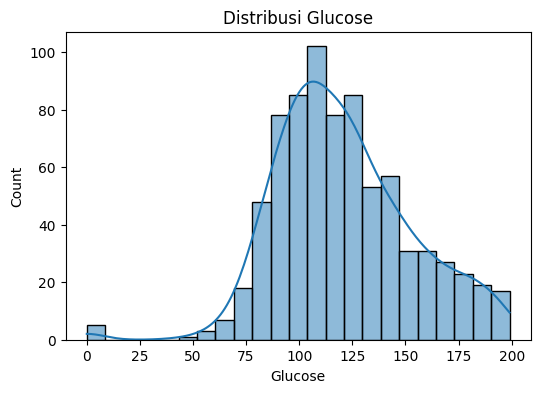

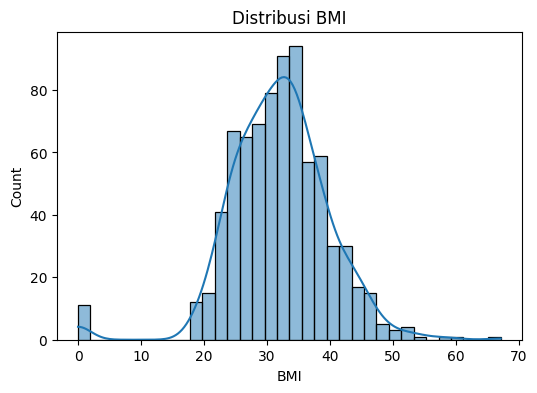

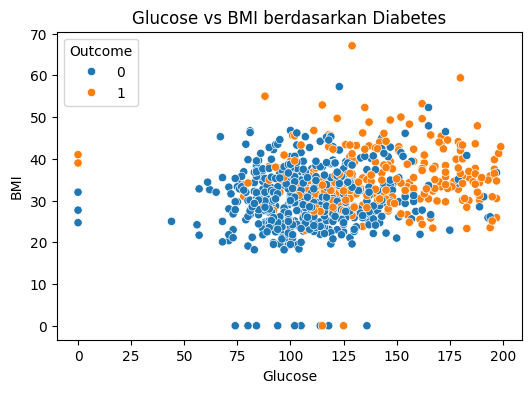

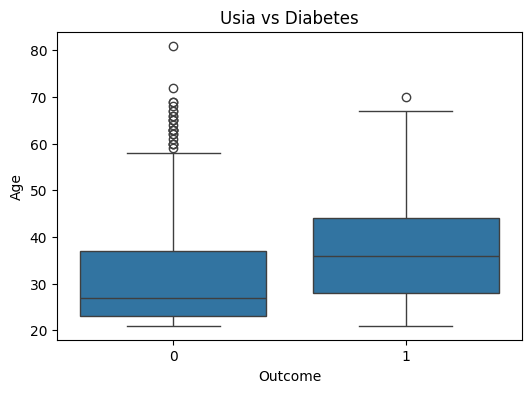

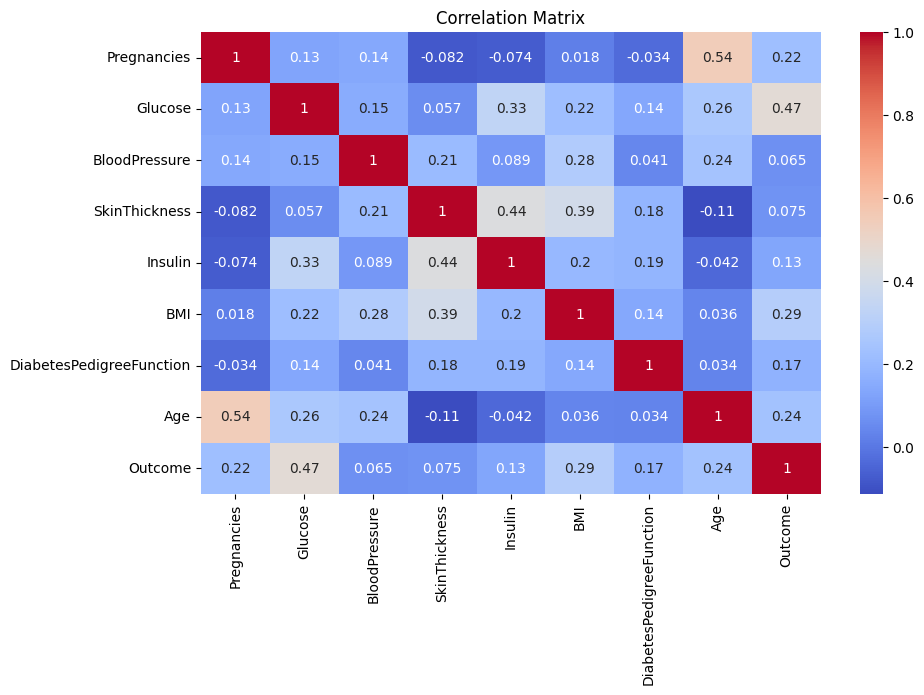

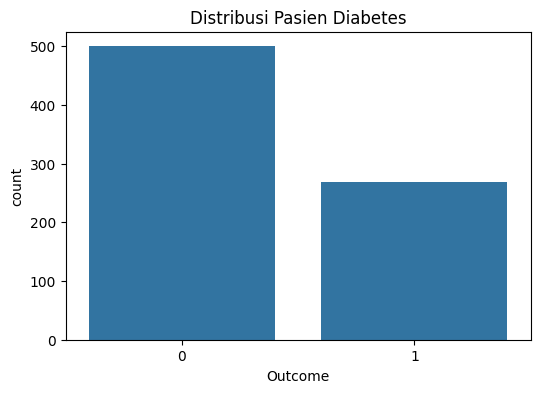

In [12]:

# 2: EXPLORATORY DATA ANALYSIS (EDA)

import seaborn as sns
import matplotlib.pyplot as plt

print("=" * 60)
print("2. EXPLORATORY DATA ANALYSIS")
print("=" * 60)


# Cek Missing Value
print("\nMissing Value:")
print(df.isnull().sum())

# Statistik dasar
print("\nStatistik Deskriptif:")
print(df.describe())


# Visualisasi 1 — Distribusi Glucose

plt.figure(figsize=(6,4))
sns.histplot(df["Glucose"], kde=True)
plt.title("Distribusi Glucose")
plt.show()


# Visualisasi 2 — Distribusi BMI

plt.figure(figsize=(6,4))
sns.histplot(df["BMI"], kde=True)
plt.title("Distribusi BMI")
plt.show()


# Visualisasi 3 — Scatter Plot Glucose vs BMI

plt.figure(figsize=(6,4))
sns.scatterplot(x="Glucose", y="BMI", hue="Outcome", data=df)
plt.title("Glucose vs BMI berdasarkan Diabetes")
plt.show()


# Visualisasi 4 — Boxplot Age vs Outcome

plt.figure(figsize=(6,4))
sns.boxplot(x="Outcome", y="Age", data=df)
plt.title("Usia vs Diabetes")
plt.show()


# Visualisasi 5 — Correlation Heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


# Visualisasi 6 — Countplot Outcome

plt.figure(figsize=(6,4))
sns.countplot(x="Outcome", data=df)
plt.title("Distribusi Pasien Diabetes")
plt.show()

In [16]:

# 3: PREPROCESSING


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("3. PREPROCESSING")
print("=" * 60)


# 1. Cek Missing Value

# Mengecek apakah terdapat nilai kosong pada dataset
# Missing value dapat menyebabkan model tidak dapat belajar dengan baik
print("\nCek Missing Value:")
print(df.isnull().sum())

# Jika terdapat missing value, maka diisi dengan nilai rata-rata (mean)
# Tujuannya agar data tidak hilang dan tetap dapat digunakan untuk training
df = df.fillna(df.mean())

print("\nMissing value telah ditangani dengan metode mean (jika ada).")


# 2. Encoding

# Encoding digunakan untuk mengubah data kategorikal menjadi numerik
# Namun pada dataset ini semua fitur sudah berupa angka
# sehingga encoding tidak diperlukan
print("\nEncoding tidak dilakukan karena semua fitur sudah numerik.")



# 3. Split Data Train-Test

# Memisahkan fitur (X) dan target (y)
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

# Membagi dataset menjadi data training dan data testing
# 80% data digunakan untuk melatih model
# 20% data digunakan untuk menguji performa model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nData berhasil dibagi menjadi train dan test")
print("Ukuran Data Train:", X_train.shape)
print("Ukuran Data Test :", X_test.shape)


# 4. Scaling Data

# Scaling dilakukan agar semua fitur memiliki skala yang sama
# Hal ini penting karena beberapa algoritma Machine Learning
# sensitif terhadap perbedaan skala antar fitur
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling selesai dilakukan menggunakan StandardScaler.")

3. PREPROCESSING

Cek Missing Value:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Missing value telah ditangani dengan metode mean (jika ada).

Encoding tidak dilakukan karena semua fitur sudah numerik.

Data berhasil dibagi menjadi train dan test
Ukuran Data Train: (614, 8)
Ukuran Data Test : (154, 8)

Scaling selesai dilakukan menggunakan StandardScaler.


In [ ]:

# 4: MODELING

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

print("=" * 60)
print("4. MODELING")
print("=" * 60)

# Menggunakan 3 model classification yang berbeda
# Tujuannya untuk membandingkan performa masing-masing model
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = []

# Training dan evaluasi setiap model
for name, model in models.items():

    # Training model menggunakan data training
    model.fit(X_train_scaled, y_train)

    # Melakukan prediksi pada data test
    y_pred = model.predict(X_test_scaled)

    # Menghitung akurasi model
    acc = accuracy_score(y_test, y_pred)

    # Menyimpan hasil evaluasi
    results.append([name, acc])

    print(f"{name} Accuracy: {acc:.3f}")


# Membuat tabel perbandingan metrik
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])

print("\nTabel Perbandingan Model")
print(results_df)

4. MODELING
Logistic Regression Accuracy: 0.753
Decision Tree Accuracy: 0.760
Random Forest Accuracy: 0.740

Tabel Perbandingan Model
                 Model  Accuracy
0  Logistic Regression  0.753247
1        Decision Tree  0.759740
2        Random Forest  0.740260


In [ ]:

# 5: MODEL TUNING

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("=" * 60)
print("5. MODEL TUNING")
print("=" * 60)

# Memilih model terbaik dari tahap modeling
# Pada contoh ini kita gunakan Random Forest
model = RandomForestClassifier(random_state=42)

# Menentukan parameter yang akan diuji
param_grid = {
    "n_estimators": [50, 100, 200],   # jumlah pohon
    "max_depth": [None, 5, 10],       # kedalaman pohon
    "min_samples_split": [2, 5]       # minimal data untuk split
}

# GridSearchCV mencoba semua kombinasi parameter
# untuk mencari model dengan performa terbaik
grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Training GridSearch
grid_search.fit(X_train_scaled, y_train)

print("\nParameter Terbaik:")
print(grid_search.best_params_)

print("\nSkor Cross Validation Terbaik:")
print(grid_search.best_score_)

# Menggunakan model terbaik untuk prediksi
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)

print("\nAkurasi Model Setelah Tuning:", acc)

5. MODEL TUNING

Parameter Terbaik:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}

Skor Cross Validation Terbaik:
0.7817939490870318

Akurasi Model Setelah Tuning: 0.7402597402597403
